# Maritime speed prediction - baseline models

## Goal
Build and evaluate models predicting **SOG (Speed Over Ground)** as a function of environmental conditions and observed trajectory context. Then compare two scenarios: *baseline* (no rotor contribution) vs *with rotors*.

## Model hierarchy
| # | Model | Purpose | Description |
|---|---|---|---|
| B1 | Constant mean | naive floor | Predict the train-set mean SOG |
| B2 | Linear weather baseline | explanation | `SOG = f(U_wind, H_s, alpha)` |
| M1 | XGBoost weather-only | explanation | Weather, waves, currents, course, and interactions — no target-history features |
| M2 | XGBoost lagged nowcast | prediction | M1 features plus previous observed SOG and apparent-wind context |

## Validation strategy
**Voyage-based split** — training and test sets contain different voyages. This prevents temporal leakage across voyage groups and matches the deployment scenario where we predict a new voyage.

## 0. Setup

In [1]:
!pip install xgboost folium



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

os.environ['LDFLAGS'] = '-L/opt/homebrew/opt/libomp/lib'
os.environ['CPPFLAGS'] = '-I/opt/homebrew/opt/libomp/include'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import RegularGridInterpolator
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

plt.style.use('seaborn-v0_8-darkgrid')

DATA_PATH = '../data/MasterSet_features.csv'
RESULTS_PATH = '../results/'

## 1. Load data

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=['Time'])
df = df.sort_values('Time').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Voyages: {df['Voyage_ID'].nunique()}")
print(f"Time range: {df['Time'].min()} → {df['Time'].max()}")
print(f"\nTarget (Speed_kn):")
print(df['Speed_kn'].describe().round(2))

Shape: (125160, 57)
Voyages: 528
Time range: 2023-02-02 00:06:00 → 2026-02-02 07:25:00

Target (Speed_kn):
count    125160.00
mean         11.52
std           2.15
min           5.00
25%          10.10
50%          11.70
75%          12.80
max          20.00
Name: Speed_kn, dtype: float64


## 2. Feature selection and voyage-based split

Features are grouped into:
- **Core** (spec base model): `True_Wind_Speed_ms`, `H_s`, `alpha_deg`
- **Extended**: add current vector, wave period, gusts

Split: sort voyages chronologically, use the last 20% as test set.

In [4]:
TARGET = 'Speed_kn'

# BASELINE MODELS
# B1: constant mean (no features needed)
# B2: simple linear regression with core weather features only
FEATURES_BASE = ['True_Wind_Speed_ms', 'H_s', 'alpha_sin', 'alpha_cos']

# M1: WEATHER-ONLY EXPLANATORY MODEL
# no target-history features. This is the model to interpret metocean effects.
FEATURES_WEATHER = [
    # core spec features (encoded)
    'True_Wind_Speed_ms', 'H_s', 'alpha_sin', 'alpha_cos',
    'wind_speed_sq',

    # course information (using raw degree for now, not encoded)
    'Course_deg',

    # wave features
    'mwp', 'wave_period_sq', 'wave_wind_alignment',

    # current effects
    'Current_Speed_ms', 'current_dir_sin', 'current_dir_cos',
    'current_along_course', 'current_cross_course',

    # gust feature
    'fg10',

    # interactions using forecast-available metocean and route context
    'wind_x_angle_sin', 'wind_x_angle_cos',
    'wind_x_wave', 'current_x_course_help',
]

# M2: LAGGED NOWCAST MODEL
# adding previous observed SOG and apparent-wind features for short-horizon prediction.
FEATURES_LAGGED = ['Speed_kn_lag1', 'Speed_kn_lag2', 'Speed_kn_mean3']
FEATURES_APPARENT = [
    'Apparent_Wind_Speed_ms', 'app_alpha_sin', 'app_alpha_cos',
    'app_wind_speed_sq', 'app_wind_x_angle_sin', 'app_wind_x_angle_cos',
    'app_wind_x_wave',
]
FEATURES_NOWCAST = FEATURES_WEATHER + FEATURES_LAGGED + FEATURES_APPARENT

# backward-compatible alias for later scenario/plot cells.
FEATURES_EXT = FEATURES_NOWCAST

# voyage-based chronological split: last 20% of voyages → test
voyage_order = (
    df.groupby('Voyage_ID')['Time'].min()
    .sort_values()
    .index.tolist()
)
split_idx = int(len(voyage_order) * 0.8)
train_voyages = set(voyage_order[:split_idx])
test_voyages  = set(voyage_order[split_idx:])

train_mask = df['Voyage_ID'].isin(train_voyages)
test_mask  = df['Voyage_ID'].isin(test_voyages)

required_features = sorted(set(FEATURES_BASE + FEATURES_WEATHER + FEATURES_NOWCAST))
df_train = df[train_mask].dropna(subset=required_features + [TARGET])
df_test  = df[test_mask].dropna(subset=required_features + [TARGET])

print(f"Train: {len(df_train):,} rows, {len(train_voyages)} voyages")
print(f"Test: {len(df_test):,} rows, {len(test_voyages)} voyages")
print(f"Train time: {df_train['Time'].min().date()} -> {df_train['Time'].max().date()}")
print(f"Test time: {df_test['Time'].min().date()} -> {df_test['Time'].max().date()}")
print(f"\nNo temporal leakage: {df_train['Time'].max() < df_test['Time'].min()}")
print(f"\nFeatures used in baseline 2 (B2): {len(FEATURES_BASE)}")
print(f"Features used in weather-only model (M1): {len(FEATURES_WEATHER)}")
print(f"Features used in lagged nowcast model (M2): {len(FEATURES_NOWCAST)}")
print(f"Lagged target features reserved for M2 only: {FEATURES_LAGGED}")
print(f"Apparent-wind features reserved for M2 only: {FEATURES_APPARENT}")

Train: 88,346 rows, 422 voyages
Test: 35,758 rows, 106 voyages
Train time: 2023-02-02 -> 2025-05-23
Test time: 2025-05-23 -> 2026-02-02

No temporal leakage: True

Features used in baseline 2 (B2): 4
Features used in weather-only model (M1): 19
Features used in lagged nowcast model (M2): 29
Lagged target features reserved for M2 only: ['Speed_kn_lag1', 'Speed_kn_lag2', 'Speed_kn_mean3']
Apparent-wind features reserved for M2 only: ['Apparent_Wind_Speed_ms', 'app_alpha_sin', 'app_alpha_cos', 'app_wind_speed_sq', 'app_wind_x_angle_sin', 'app_wind_x_angle_cos', 'app_wind_x_wave']


## 3. Baseline 1 - constant mean speed

Predicts the training-set mean SOG for every test observation. Sets the floor for model performance.

In [5]:
y_train = df_train[TARGET].values
y_test  = df_test[TARGET].values

mean_speed = y_train.mean()
y_pred_b1  = np.full_like(y_test, mean_speed)

results = {}

def eval_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    within_1kn = np.mean(np.abs(y_pred - y_true) <= 1.0) * 100
    results[name] = dict(MAE=mae, RMSE=rmse, R2=r2, within_1kn=within_1kn)
    print(f"{name:30s}  MAE={mae:.3f} kn  RMSE={rmse:.3f} kn  R²={r2:.3f}  within±1kn={within_1kn:.1f}%")

eval_metrics(y_test, y_pred_b1, 'B1: Constant mean')
print(f"(mean speed = {mean_speed:.2f} kn)")

B1: Constant mean               MAE=1.388 kn  RMSE=1.893 kn  R²=-0.002  within±1kn=49.3%
(mean speed = 11.56 kn)


## 4. Baseline 2 - linear regression 

Per spec: simple linear regression with wind speed and wave height.

In [6]:
scaler_b2 = StandardScaler()
X_train_b2 = scaler_b2.fit_transform(df_train[FEATURES_BASE])
X_test_b2  = scaler_b2.transform(df_test[FEATURES_BASE])

lr = LinearRegression()
lr.fit(X_train_b2, y_train)
y_pred_b2 = lr.predict(X_test_b2)

eval_metrics(y_test, y_pred_b2, 'B2: Linear (wind+wave+α encoded)')

print("\n" + "="*60)
print("Linear regression coefficients (normalized features):")
print("="*60)
for feat, coef in zip(FEATURES_BASE, lr.coef_):
    print(f"  {feat:<35s}: {coef:+.6f}")
print(f"  {'intercept':<35s}: {lr.intercept_:+.6f}")
print(f"\nModel explains {results['B2: Linear (wind+wave+α encoded)']['R2']:.1%} of variance")

B2: Linear (wind+wave+α encoded)  MAE=1.377 kn  RMSE=1.860 kn  R²=0.034  within±1kn=49.5%

Linear regression coefficients (normalized features):
  True_Wind_Speed_ms                 : +0.233049
  H_s                                : -0.062356
  alpha_sin                          : -0.009911
  alpha_cos                          : -0.278299
  intercept                          : +11.560826

Model explains 3.4% of variance


## 5. Main models - weather-only vs lagged nowcast

In [7]:
def fit_xgb_model(feature_cols, label):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(df_train[feature_cols])
    X_test = scaler.transform(df_test[feature_cols])

    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    eval_metrics(y_test, pred, label)
    return model, scaler, pred

model_weather, scaler_weather, y_pred_weather = fit_xgb_model(
    FEATURES_WEATHER,
    'M1: XGBoost (weather-only)'
)

model_xgb, scaler_xgb, y_pred_xgb = fit_xgb_model(
    FEATURES_NOWCAST,
    'M2: XGBoost (lagged nowcast)'
)

M1: XGBoost (weather-only)      MAE=1.468 kn  RMSE=1.883 kn  R²=0.010  within±1kn=41.7%
M2: XGBoost (lagged nowcast)    MAE=0.406 kn  RMSE=0.758 kn  R²=0.839  within±1kn=91.7%


## 6. Model comparison

In [8]:
summary = pd.DataFrame(results).T.round(3)
summary.index.name = 'Model'
print(summary.to_string())

                                    MAE   RMSE     R2  within_1kn
Model                                                            
B1: Constant mean                 1.388  1.893 -0.002      49.251
B2: Linear (wind+wave+α encoded)  1.377  1.860  0.034      49.474
M1: XGBoost (weather-only)        1.468  1.883  0.010      41.742
M2: XGBoost (lagged nowcast)      0.406  0.758  0.839      91.711


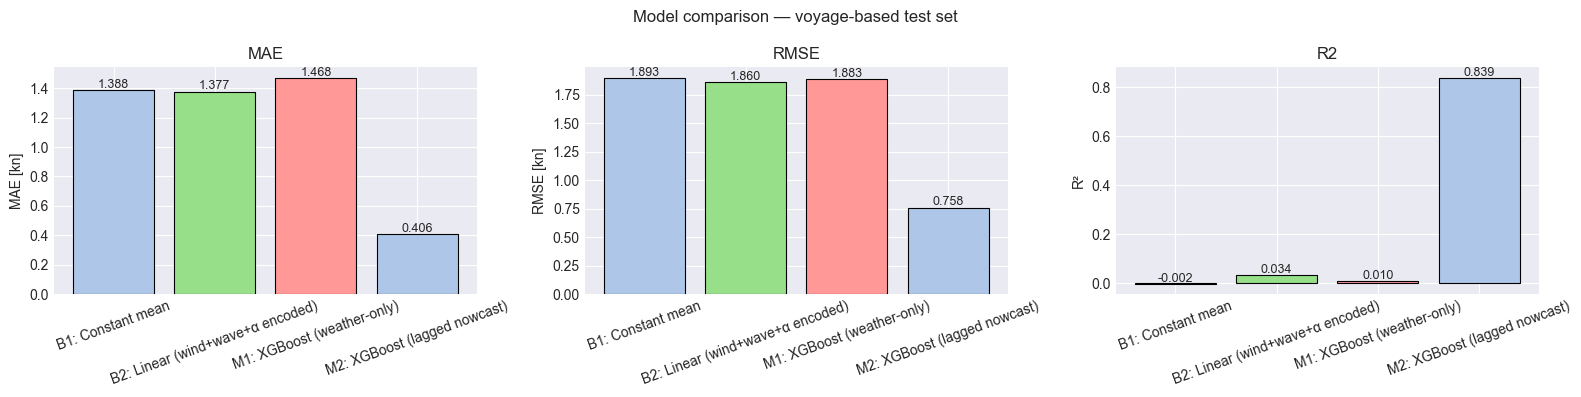

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
model_names = list(results.keys())
colors = ['#aec7e8', '#98df8a', '#ff9896']

for ax, metric, ylabel in zip(
    axes,
    ['MAE', 'RMSE', 'R2'],
    ['MAE [kn]', 'RMSE [kn]', 'R²']
):
    vals = [results[m][metric] for m in model_names]
    ax.bar(model_names, vals, color=colors, edgecolor='black', linewidth=0.8)
    ax.set_title(metric)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals)*0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Model comparison — voyage-based test set', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Predicted vs actual

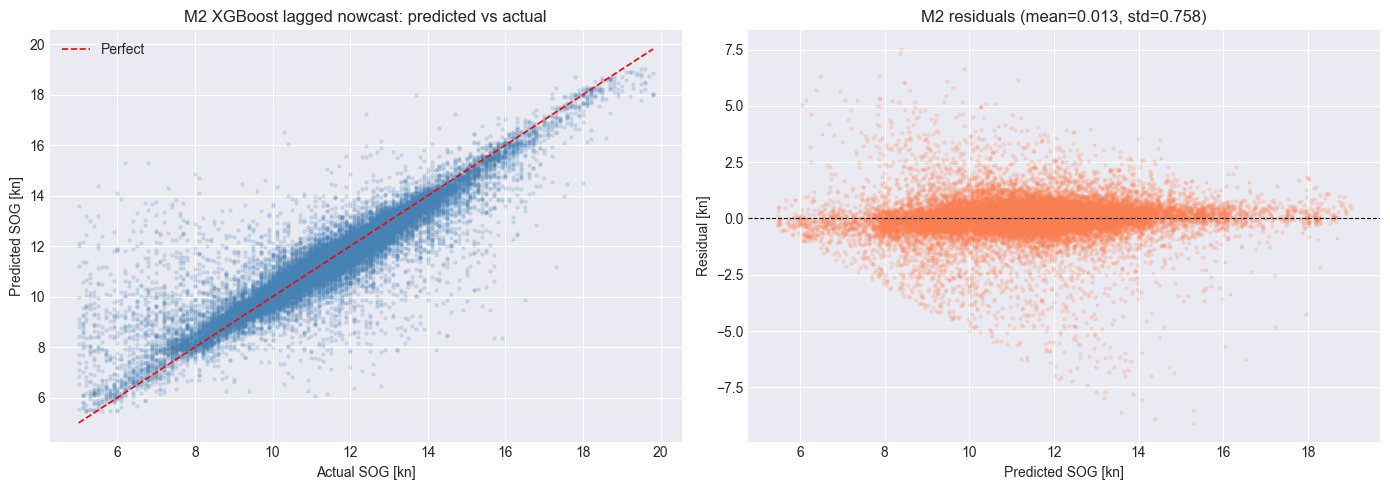

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# predicted vs actual
axes[0].scatter(y_test, y_pred_xgb, alpha=0.15, s=5, color='steelblue')
lims = [min(y_test.min(), y_pred_xgb.min()), max(y_test.max(), y_pred_xgb.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.2, label='Perfect')
axes[0].set_xlabel('Actual SOG [kn]')
axes[0].set_ylabel('Predicted SOG [kn]')
axes[0].set_title('M2 XGBoost lagged nowcast: predicted vs actual')
axes[0].legend()

# residuals
residuals = y_test - y_pred_xgb
axes[1].scatter(y_pred_xgb, residuals, alpha=0.15, s=5, color='coral')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Predicted SOG [kn]')
axes[1].set_ylabel('Residual [kn]')
axes[1].set_title(f'M2 residuals (mean={residuals.mean():.3f}, std={residuals.std():.3f})')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature importance

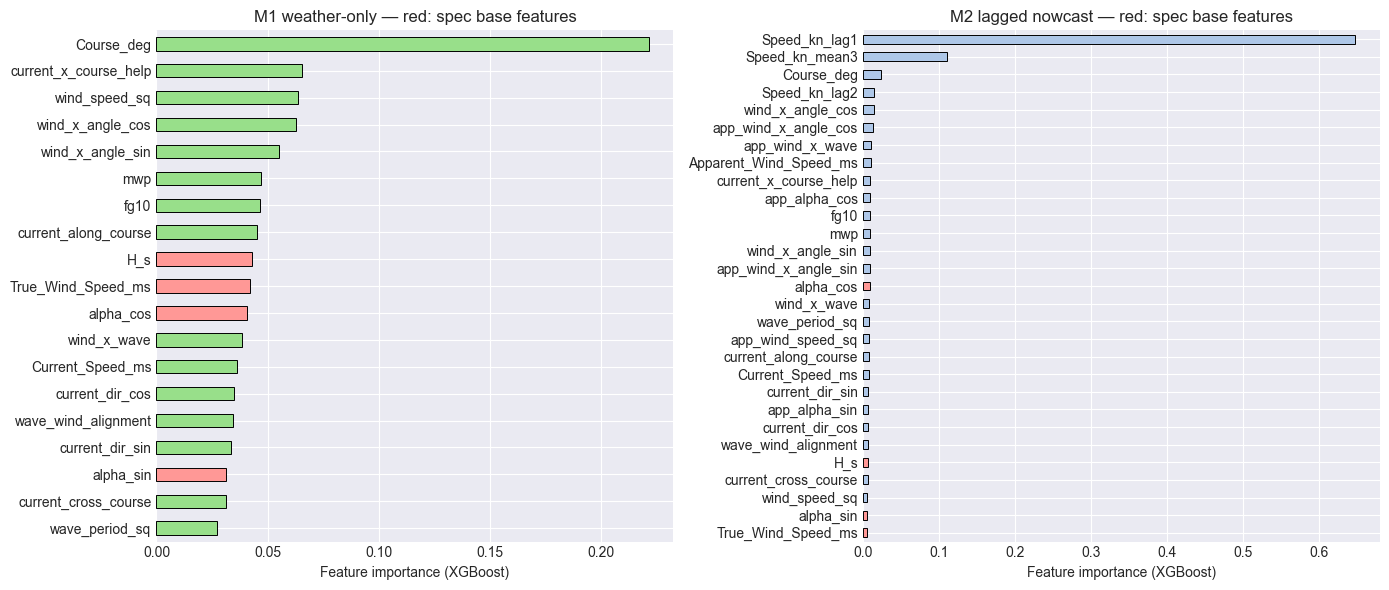


M1 weather-only core spec cumulative importance: 0.157
M1 weather-only alpha (sin+cos) cumulative importance: 0.072
M2 lagged nowcast core spec cumulative importance: 0.025
M2 lagged nowcast alpha (sin+cos) cumulative importance: 0.013


In [11]:
importances = pd.Series(model_xgb.feature_importances_, index=FEATURES_NOWCAST).sort_values(ascending=True)
weather_importances = pd.Series(model_weather.feature_importances_, index=FEATURES_WEATHER).sort_values(ascending=True)

# core features now use encoded alpha instead of raw alpha_deg
core_spec_features = ['True_Wind_Speed_ms', 'H_s', 'alpha_sin', 'alpha_cos']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_weather = ['#ff9896' if f in core_spec_features else '#98df8a' for f in weather_importances.index]
weather_importances.plot.barh(ax=axes[0], color=colors_weather, edgecolor='black', linewidth=0.7)
axes[0].set_xlabel('Feature importance (XGBoost)')
axes[0].set_title('M1 weather-only — red: spec base features')

colors_nowcast = ['#ff9896' if f in core_spec_features else '#aec7e8' for f in importances.index]
importances.plot.barh(ax=axes[1], color=colors_nowcast, edgecolor='black', linewidth=0.7)
axes[1].set_xlabel('Feature importance (XGBoost)')
axes[1].set_title('M2 lagged nowcast — red: spec base features')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

core_available = [f for f in core_spec_features if f in importances.index]
core_importance = importances[core_available].sum()
alpha_importance = importances[[f for f in ['alpha_sin', 'alpha_cos'] if f in importances.index]].sum()

weather_core_available = [f for f in core_spec_features if f in weather_importances.index]
weather_core_importance = weather_importances[weather_core_available].sum()
weather_alpha_importance = weather_importances[[f for f in ['alpha_sin', 'alpha_cos'] if f in weather_importances.index]].sum()

print("\nM1 weather-only core spec cumulative importance:", f"{weather_core_importance:.3f}")
print("M1 weather-only alpha (sin+cos) cumulative importance:", f"{weather_alpha_importance:.3f}")
print("M2 lagged nowcast core spec cumulative importance:", f"{core_importance:.3f}")
print("M2 lagged nowcast alpha (sin+cos) cumulative importance:", f"{alpha_importance:.3f}")

## 9. Rotor what-if scenario

Using the rotor polar diagram (from `feature_engineering.ipynb`), we estimate the expected rotor power contribution for each test observation. Since the training data was collected with rotors operating, we use this as the *with-rotors* baseline. The *without-rotors* counterfactual subtracts the estimated rotor power, converted to a speed equivalent.

An approximation at ~12 kn is `ΔV [kn] ≈ P_rotor [kW] / 200`. This assumes a linear thrust-speed relationship around the operating point and is suitable for planning-level scenario comparison.

In [12]:
# rotor polar diagram (same as feature_engineering.ipynb)
WIND_SPEEDS = np.array([4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24])
WIND_ANGLES = np.array([0, 20, 40, 60, 80, 90, 100, 120, 140, 160, 180])
POWER_TABLE = np.array([
    [  0,   3,  10,  14,  16,  14,  12,   7,   3,   1,   0],
    [ -2,   6,  22,  38,  44,  42,  38,  22,   9,   3,   0],
    [ -5,  12,  45,  78,  90,  87,  78,  46,  19,   7,   0],
    [ -8,  20,  75, 128, 148, 144, 130,  76,  32,  11,   0],
    [-12,  30, 110, 186, 215, 210, 188, 110,  46,  16,   0],
    [-16,  42, 152, 256, 297, 290, 260, 152,  64,  22,   0],
    [-21,  56, 200, 335, 390, 380, 340, 199,  83,  29,   0],
    [-27,  72, 254, 425, 496, 484, 433, 254, 106,  37,   0],
    [-33,  90, 315, 526, 614, 599, 537, 314, 131,  46,   0],
    [-40, 110, 382, 638, 745, 727, 651, 381, 159,  55,   0],
    [-48, 132, 456, 762, 890, 868, 778, 455, 190,  66,   0],
])

_interp = RegularGridInterpolator(
    (WIND_SPEEDS, WIND_ANGLES), POWER_TABLE, method='linear',
    bounds_error=False, fill_value=None
)

def rotor_power_kw(wind_ms, alpha_abs):
    ws = np.clip(np.asarray(wind_ms, float), WIND_SPEEDS.min(), WIND_SPEEDS.max())
    wa = np.clip(np.asarray(alpha_abs, float), WIND_ANGLES.min(), WIND_ANGLES.max())
    return _interp(np.column_stack([ws.ravel(), wa.ravel()])).reshape(ws.shape)


KW_PER_KN = 200.0  # conversion: 200 kW ~= 1 kn at operating point

# rotor contribution on test set
p_rotor = rotor_power_kw(
    df_test['True_Wind_Speed_ms'].values,
    df_test['alpha_abs_deg'].values
)

# rotor active: positive power, H_s ≤ 6, wind ≤ 42
active = (p_rotor > 0) & (df_test['H_s'].values <= 6.0) & (df_test['True_Wind_Speed_ms'].values <= 42.0)

delta_v = np.where(active, p_rotor / KW_PER_KN, 0.0)

# with-rotor prediction = XGBoost prediction (trained on data with rotors operating)
# without-rotor counterfactual = subtract the estimated rotor contribution
y_pred_with_rotor    = y_pred_xgb
y_pred_without_rotor = y_pred_xgb - delta_v

print(f"Rotor active: {active.sum():,} / {len(active):,} rows ({active.mean()*100:.1f}%)")
print(f"Mean rotor power when active: {p_rotor[active].mean():.1f} kW")
print(f"Mean delta_SOG when active: {delta_v[active].mean():.3f} kn")
print(f"Overall mean delta_SOG: {delta_v.mean():.3f} kn")

Rotor active: 35,077 / 35,758 rows (98.1%)
Mean rotor power when active: 41.2 kW
Mean delta_SOG when active: 0.206 kn
Overall mean delta_SOG: 0.202 kn


In [13]:
# per-voyage rotor benefit
df_test_copy = df_test.copy()
df_test_copy['pred_with_rotor'] = y_pred_with_rotor
df_test_copy['pred_without_rotor'] = y_pred_without_rotor
df_test_copy['delta_v'] = delta_v
df_test_copy['rotor_active'] = active.astype(int)

voyage_summary = df_test_copy.groupby('Voyage_ID').agg(
    n_points = ('Speed_kn', 'count'),
    mean_sog_actual = ('Speed_kn', 'mean'),
    mean_sog_pred = ('pred_with_rotor', 'mean'),
    mean_sog_no_rot = ('pred_without_rotor', 'mean'),
    rotor_active_pct= ('rotor_active', 'mean'),
    mean_delta_v = ('delta_v', 'mean'),
).round(3)

voyage_summary['delta_v_kn'] = (voyage_summary['mean_sog_pred'] - voyage_summary['mean_sog_no_rot']).round(3)

print("Per-voyage rotor scenario summary (test set):")
print(voyage_summary.sort_values('mean_delta_v', ascending=False).head(10).to_string())

Per-voyage rotor scenario summary (test set):
           n_points  mean_sog_actual  mean_sog_pred  mean_sog_no_rot  rotor_active_pct  mean_delta_v  delta_v_kn
Voyage_ID                                                                                                       
501             142           12.977         12.789           11.600             1.000         1.189       1.189
488             125           14.130         14.094           13.318             1.000         0.776       0.776
456             511           11.501         11.544           10.801             1.000         0.743       0.743
520             328           11.840         11.980           11.301             0.988         0.679       0.679
474             495           11.784         11.794           11.216             0.998         0.578       0.578
525             951           11.829         11.805           11.271             0.999         0.534       0.534
492             125           13.522         13.35

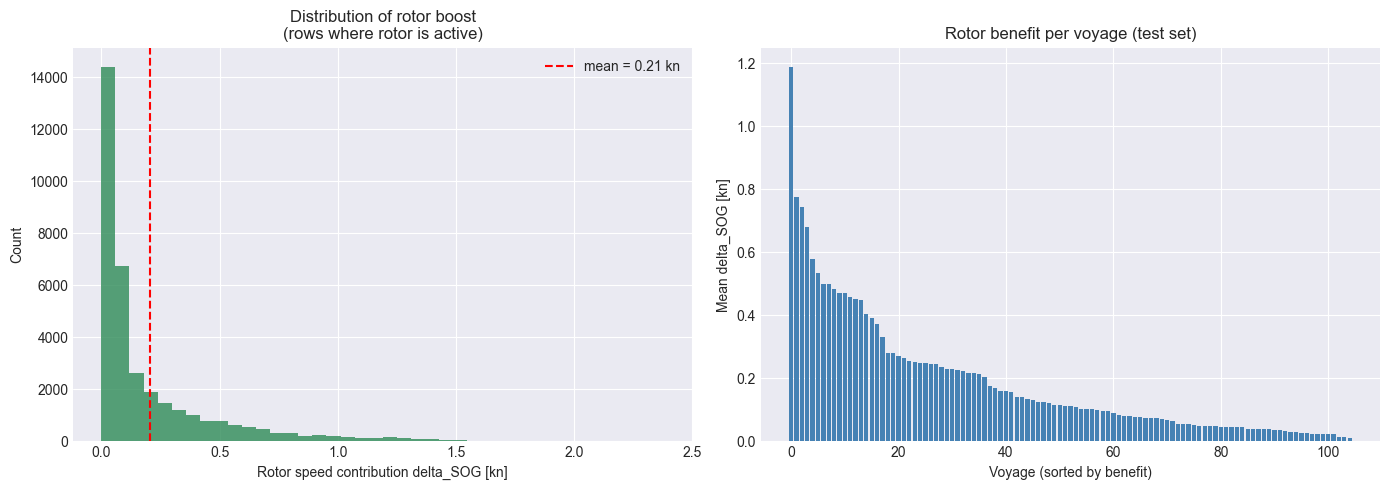

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram of delta_SOG
axes[0].hist(delta_v[active], bins=40, color='seagreen', edgecolor='none', alpha=0.8)
axes[0].axvline(delta_v[active].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'mean = {delta_v[active].mean():.2f} kn')
axes[0].set_xlabel('Rotor speed contribution delta_SOG [kn]')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of rotor boost\n(rows where rotor is active)')
axes[0].legend()

# per-voyage mean delta_SOG
dvs = voyage_summary['mean_delta_v'].sort_values(ascending=False)
axes[1].bar(range(len(dvs)), dvs.values, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Voyage (sorted by benefit)')
axes[1].set_ylabel('Mean delta_SOG [kn]')
axes[1].set_title('Rotor benefit per voyage (test set)')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'rotor_scenario.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Weather window analysis

A weather window is a contiguous time interval where:
- Predicted SOG >= threshold (e.g. 10 kn)
- H_s <= threshold (e.g. 3 m)

We compare window counts and lengths between the baseline (no rotor) and with-rotor scenarios.

In [15]:
SOG_THRESHOLD = 10.0   # minimum speed [kn]
HS_THRESHOLD  = 3.0    # maximum wave height [m]

def count_windows(sog_series, hs_series, sog_min, hs_max):
    """Counting contiguous windows meeting both conditions."""
    in_window = (sog_series >= sog_min) & (hs_series <= hs_max)
    # counting transitions false to true
    starts = np.sum(~in_window.values[:-1] & in_window.values[1:])
    if in_window.values[0]:
        starts += 1
    total_points = in_window.sum()
    return int(starts), int(total_points)


hs_test = df_test['H_s'].values

n_win_base, pts_base = count_windows(
    pd.Series(y_pred_without_rotor), pd.Series(hs_test), SOG_THRESHOLD, HS_THRESHOLD)
n_win_rot,  pts_rot  = count_windows(
    pd.Series(y_pred_with_rotor),    pd.Series(hs_test), SOG_THRESHOLD, HS_THRESHOLD)

total = len(y_pred_xgb)
print(f"Weather window definition: SOG >= {SOG_THRESHOLD} kn  AND  H_s <= {HS_THRESHOLD} m")
print(f"")
print(f"{'Scenario':<25} {'Windows':>10} {'Points in window':>18} {'Coverage':>10}")
print("-" * 65)
print(f"{'Without rotor':<25} {n_win_base:>10} {pts_base:>18,} {pts_base/total*100:>9.1f}%")
print(f"{'With rotor':<25} {n_win_rot:>10} {pts_rot:>18,} {pts_rot/total*100:>9.1f}%")
print(f"{'Delta':<25} {n_win_rot-n_win_base:>+10} {pts_rot-pts_base:>+18,} {(pts_rot-pts_base)/total*100:>+9.1f}%")

Weather window definition: SOG >= 10.0 kn  AND  H_s <= 3.0 m

Scenario                     Windows   Points in window   Coverage
-----------------------------------------------------------------
Without rotor                    866             27,167      76.0%
With rotor                       808             27,696      77.5%
Delta                            -58               +529      +1.5%


## 11. Summary

In [16]:

print("MARITIME SPEED PREDICTION — SUMMARY")

print(f"Target: Speed_kn (SOG)")
print(f"Train: {len(train_voyages)} voyages ({len(df_train):,} rows)")
print(f"Test: {len(test_voyages)} voyages ({len(df_test):,} rows) [chronological split]")
print()
print(f"{'Model':<30} {'MAE [kn]':>10} {'RMSE [kn]':>10} {'R^2':>8}")
print("-" * 60)
for name, m in results.items():
    print(f"{name:<30} {m['MAE']:>10.3f} {m['RMSE']:>10.3f} {m['R2']:>8.3f}")
print()
print(f"Rotor active (test set): {active.mean()*100:.1f}% of observations")
print(f"Mean rotor delta_SOG (active): {delta_v[active].mean():.3f} kn")
print(f"Weather window coverage: {pts_base/total*100:.1f}% -> {pts_rot/total*100:.1f}% (with rotors)")

MARITIME SPEED PREDICTION — SUMMARY
Target: Speed_kn (SOG)
Train: 422 voyages (88,346 rows)
Test: 106 voyages (35,758 rows) [chronological split]

Model                            MAE [kn]  RMSE [kn]      R^2
------------------------------------------------------------
B1: Constant mean                   1.388      1.893   -0.002
B2: Linear (wind+wave+α encoded)      1.377      1.860    0.034
M1: XGBoost (weather-only)          1.468      1.883    0.010
M2: XGBoost (lagged nowcast)        0.406      0.758    0.839

Rotor active (test set): 98.1% of observations
Mean rotor delta_SOG (active): 0.206 kn
Weather window coverage: 76.0% -> 77.5% (with rotors)


## 12. Trajectory visualization with OpenStreetMap overlay

The voyage visualisations below use `folium` with OpenStreetMap tiles. This gives the raw AIS-derived tracks geographical context while keeping the map interactive in the notebook. The exported HTML files can be opened directly from `results/`.


In [17]:
# Map 1 - are trips overlapping?
# Folium renders interactive OpenStreetMap-based maps directly in the notebook.
# It also saves standalone HTML versions to the results folder.
try:
    import folium
    from folium.plugins import MiniMap, Fullscreen, MeasureControl
    from IPython.display import display
except ImportError as exc:
    raise ImportError(
        "This cell requires folium. Install project requirements or run: pip install folium"
    ) from exc


OSM_RESULTS_PATH = RESULTS_PATH
MAX_POINTS_PER_VOYAGE = 120


def _sample_track(track, max_points=MAX_POINTS_PER_VOYAGE):
    """Keep maps responsive by downsampling long AIS tracks for display only."""
    track = track.sort_values('Time') if 'Time' in track.columns else track
    if len(track) <= max_points:
        return track
    idx = np.linspace(0, len(track) - 1, max_points).astype(int)
    return track.iloc[np.unique(idx)]


def _map_center(data):
    return [float(data['Lat'].median()), float(data['Lon'].median())]


def _fit_bounds(map_obj, data, pad=0.08):
    lat_min, lat_max = float(data['Lat'].min()), float(data['Lat'].max())
    lon_min, lon_max = float(data['Lon'].min()), float(data['Lon'].max())
    map_obj.fit_bounds([
        [lat_min - pad, lon_min - pad],
        [lat_max + pad, lon_max + pad],
    ])


def _add_map_controls(map_obj):
    folium.TileLayer('OpenStreetMap', name='OpenStreetMap').add_to(map_obj)
    folium.TileLayer('CartoDB positron', name='Light map').add_to(map_obj)
    folium.TileLayer('CartoDB dark_matter', name='Dark map').add_to(map_obj)
    MiniMap(toggle_display=True, minimized=True).add_to(map_obj)
    Fullscreen(position='topright').add_to(map_obj)
    MeasureControl(position='bottomleft', primary_length_unit='nauticalmiles').add_to(map_obj)
    folium.LayerControl(collapsed=False).add_to(map_obj)


def make_all_voyages_osm_map(data, output_path):
    map_obj = folium.Map(
        location=_map_center(data),
        zoom_start=6,
        tiles=None,
        control_scale=True,
    )

    palette = [
        '#2563eb', '#dc2626', '#16a34a', '#9333ea', '#ea580c',
        '#0891b2', '#be123c', '#4f46e5', '#65a30d', '#0f766e',
    ]

    voyages_layer = folium.FeatureGroup(
        name=f'Training voyages ({data["Voyage_ID"].nunique()})',
        show=True,
    )

    for idx, (v_id, v_data) in enumerate(data.groupby('Voyage_ID', sort=False)):
        display_track = _sample_track(v_data)
        coords = display_track[['Lat', 'Lon']].dropna().values.tolist()
        if len(coords) < 2:
            continue

        folium.PolyLine(
            coords,
            color=palette[idx % len(palette)],
            weight=2,
            opacity=0.55,
            tooltip=f'Voyage {v_id} | {len(v_data):,} AIS points',
        ).add_to(voyages_layer)

    voyages_layer.add_to(map_obj)
    _fit_bounds(map_obj, data)
    _add_map_controls(map_obj)
    map_obj.save(output_path)
    return map_obj


def make_rotor_voyage_osm_map(data, voyage_id, output_path):
    v_data = data[data['Voyage_ID'] == voyage_id].copy()
    if v_data.empty:
        raise ValueError(f'Voyage {voyage_id} is not present in the provided dataframe.')

    map_obj = folium.Map(
        location=_map_center(v_data),
        zoom_start=6,
        tiles=None,
        control_scale=True,
    )

    route_layer = folium.FeatureGroup(name=f'Voyage {voyage_id} route', show=True)
    display_track = _sample_track(v_data, max_points=240)
    coords = display_track[['Lat', 'Lon']].dropna().values.tolist()
    folium.PolyLine(
        coords,
        color='#334155',
        weight=4,
        opacity=0.75,
        tooltip=f'Full trajectory for voyage {voyage_id}',
    ).add_to(route_layer)
    route_layer.add_to(map_obj)

    rotor_on_layer = folium.FeatureGroup(name='Rotor on', show=True)
    rotor_off_layer = folium.FeatureGroup(name='Rotor off', show=True)

    # Markers are sampled for readability; the underlying route line still shows the full path shape.
    for _, row in _sample_track(v_data[v_data['rotor_active'] == 1], max_points=160).iterrows():
        folium.CircleMarker(
            location=[row['Lat'], row['Lon']],
            radius=4,
            color='black',
            weight=0.5,
            fill=True,
            fill_color='mediumseagreen',
            fill_opacity=0.9,
            tooltip=f"Rotor on | {row['Time']} | SOG {row['Speed_kn']:.1f} kn",
        ).add_to(rotor_on_layer)

    for _, row in _sample_track(v_data[v_data['rotor_active'] == 0], max_points=160).iterrows():
        folium.CircleMarker(
            location=[row['Lat'], row['Lon']],
            radius=4,
            color='black',
            weight=0.5,
            fill=True,
            fill_color='crimson',
            fill_opacity=0.9,
            tooltip=f"Rotor off | {row['Time']} | SOG {row['Speed_kn']:.1f} kn",
        ).add_to(rotor_off_layer)

    rotor_on_layer.add_to(map_obj)
    rotor_off_layer.add_to(map_obj)
    _fit_bounds(map_obj, v_data)
    _add_map_controls(map_obj)
    map_obj.save(output_path)
    return map_obj


all_voyages_map = make_all_voyages_osm_map(
    df_train,
    OSM_RESULTS_PATH + 'all_trajectories_osm.html',
)
display(all_voyages_map)


# Map 2 - when is the rotor on?
voyage = 514
rotor_voyage_map = make_rotor_voyage_osm_map(
    df_test_copy,
    voyage,
    OSM_RESULTS_PATH + f'rotor_voyage_{voyage}_osm.html',
)
display(rotor_voyage_map)




In [18]:
print('=== SUMMARY ===')
print(f"Rows: train = {len(df_train):,}, test = {len(df_test):,}")
print(f"Voyages: train = {len(train_voyages)}, test = {len(test_voyages)}")
print(f"No temporal leakage: {df_train['Time'].max() < df_test['Time'].min()}")
print('')           

print('Model metrics:')
for name, m in results.items():
    print(f"- {name}: MAE = {m['MAE']:.3f}, RMSE = {m['RMSE']:.3f}, R2 = {m['R2']:.3f}, within +/- 1kn = {m['within_1kn']:.1f}%")
print('')

if 'M1: XGBoost (weather-only)' in results and 'M2: XGBoost (lagged nowcast)' in results:
    d_mae = results['M1: XGBoost (weather-only)']['MAE'] - results['M2: XGBoost (lagged nowcast)']['MAE']
    d_rmse = results['M1: XGBoost (weather-only)']['RMSE'] - results['M2: XGBoost (lagged nowcast)']['RMSE']
    print(f"Lagged nowcast gain vs weather-only: delta_MAE={d_mae:+.3f}, delta_RMSE={d_rmse:+.3f}")
print('')

print('Rotor scenario uses M2 lagged nowcast predictions:')
print(f"- Rotor active share: {active.mean()*100:.1f}%")
print(f"- Mean rotor power (active): {p_rotor[active].mean():.1f} kW")
print(f"- Mean delta_SOG (active): {delta_v[active].mean():.3f} kn")
print(f"- Mean delta_SOG (overall): {delta_v.mean():.3f} kn")
print('')

print('Weather windows (SOG >= 10, Hs <= 3):')
print(f"- Without rotor: windows = {n_win_base}, points = {pts_base:,}, coverage = {pts_base/total*100:.1f}%")
print(f"- With rotor: windows = {n_win_rot}, points = {pts_rot:,}, coverage = {pts_rot/total*100:.1f}%")
print(f"- Delta: windows = {n_win_rot-n_win_base:+d}, points = {pts_rot-pts_base:+,}, coverage = {(pts_rot-pts_base)/total*100:+.1f}%")
print('')

print('Top 10 M1 weather-only feature importances:')
print(weather_importances.sort_values(ascending=False).head(10).to_string())
print('')
print('Top 10 M2 lagged nowcast feature importances:')
print(importances.sort_values(ascending=False).head(10).to_string())
print('')
print(f"M1 weather-only core encoded spec importance: {weather_core_importance:.3f}")
print(f"M1 weather-only alpha encoded importance: {weather_alpha_importance:.3f}")
print(f"M2 lagged nowcast core encoded spec importance: {core_importance:.3f}")
print(f"M2 lagged nowcast alpha encoded importance: {alpha_importance:.3f}")

=== SUMMARY ===
Rows: train = 88,346, test = 35,758
Voyages: train = 422, test = 106
No temporal leakage: True

Model metrics:
- B1: Constant mean: MAE = 1.388, RMSE = 1.893, R2 = -0.002, within +/- 1kn = 49.3%
- B2: Linear (wind+wave+α encoded): MAE = 1.377, RMSE = 1.860, R2 = 0.034, within +/- 1kn = 49.5%
- M1: XGBoost (weather-only): MAE = 1.468, RMSE = 1.883, R2 = 0.010, within +/- 1kn = 41.7%
- M2: XGBoost (lagged nowcast): MAE = 0.406, RMSE = 0.758, R2 = 0.839, within +/- 1kn = 91.7%

Lagged nowcast gain vs weather-only: delta_MAE=+1.062, delta_RMSE=+1.124

Rotor scenario uses M2 lagged nowcast predictions:
- Rotor active share: 98.1%
- Mean rotor power (active): 41.2 kW
- Mean delta_SOG (active): 0.206 kn
- Mean delta_SOG (overall): 0.202 kn

Weather windows (SOG >= 10, Hs <= 3):
- Without rotor: windows = 866, points = 27,167, coverage = 76.0%
- With rotor: windows = 808, points = 27,696, coverage = 77.5%
- Delta: windows = -58, points = +529, coverage = +1.5%

Top 10 M1 weathe

## 13. Prediction intervals (95% confidence) using quantile regression

Ocean conditions are uncertain. Weather forecasts (ERA5, Copernicus) can differ from reality, and even with identical external conditions, ship behavior varies slightly due to load, engine settings, and unmeasured factors.

Instead of predicting a single speed, we estimate a 95% prediction interval: At 95% confidence, the ship's speed will fall between X and Y knots.

That is why we use quantile regression on ensemble models to estimate the lower 2.5th percentile and upper 97.5th percentile bounds.


In [19]:
from sklearn.ensemble import GradientBoostingRegressor

X_train_quantile = scaler_xgb.fit_transform(df_train[FEATURES_NOWCAST])
X_test_quantile  = scaler_xgb.transform(df_test[FEATURES_NOWCAST])

# quantiles for 95% confidence interval
alpha_lower = 0.025 # lower bound 2.5%
alpha_upper = 0.975 # upper bound 97.5%

# model for lower bound
model_lower = GradientBoostingRegressor(
    loss='quantile',
    alpha=alpha_lower,
    n_estimators=150,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=33,
    verbose=0
)
model_lower.fit(X_train_quantile, y_train)
y_pred_lower = model_lower.predict(X_test_quantile)

# model for upper bound
model_upper = GradientBoostingRegressor(
    loss='quantile',
    alpha=alpha_upper,
    n_estimators=150,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=33,
    verbose=0
)
model_upper.fit(X_train_quantile, y_train)
y_pred_upper = model_upper.predict(X_test_quantile)

print("PREDICTION INTERVAL RESULTS")

interval_width = y_pred_upper - y_pred_lower
interval_lower_mean = y_pred_lower.mean()
interval_upper_mean = y_pred_upper.mean()

print(f"\nMean lower bound (2.5%): {interval_lower_mean:.3f} kn")
print(f"Mean upper bound (97.5%): {interval_upper_mean:.3f} kn")
print(f"Mean interval width: {interval_width.mean():.3f} kn")
print(f"Min interval width: {interval_width.min():.3f} kn")
print(f"Max interval width: {interval_width.max():.3f} kn")

# coverage check - do actual values fall within the predicted intervals?
coverage = np.mean((y_test >= y_pred_lower) & (y_test <= y_pred_upper)) * 100
print(f"\n Actual model coverage: {coverage:.1f}%")
print(f"In {coverage:.1f}% of test observations, the actual ship speednfell within our predicted 95% prediction interval.")

if coverage >= 93 and coverage <= 97:
    print(f"Model is well-calibrated.")
elif coverage < 93:
    print(f"Coverage lower than expected.")
else:
    print(f"Coverage higher than expected.")


PREDICTION INTERVAL RESULTS

Mean lower bound (2.5%): 9.668 kn
Mean upper bound (97.5%): 12.821 kn
Mean interval width: 3.153 kn
Min interval width: 0.737 kn
Max interval width: 12.843 kn

 Actual model coverage: 96.5%
In 96.5% of test observations, the actual ship speednfell within our predicted 95% prediction interval.
Model is well-calibrated.


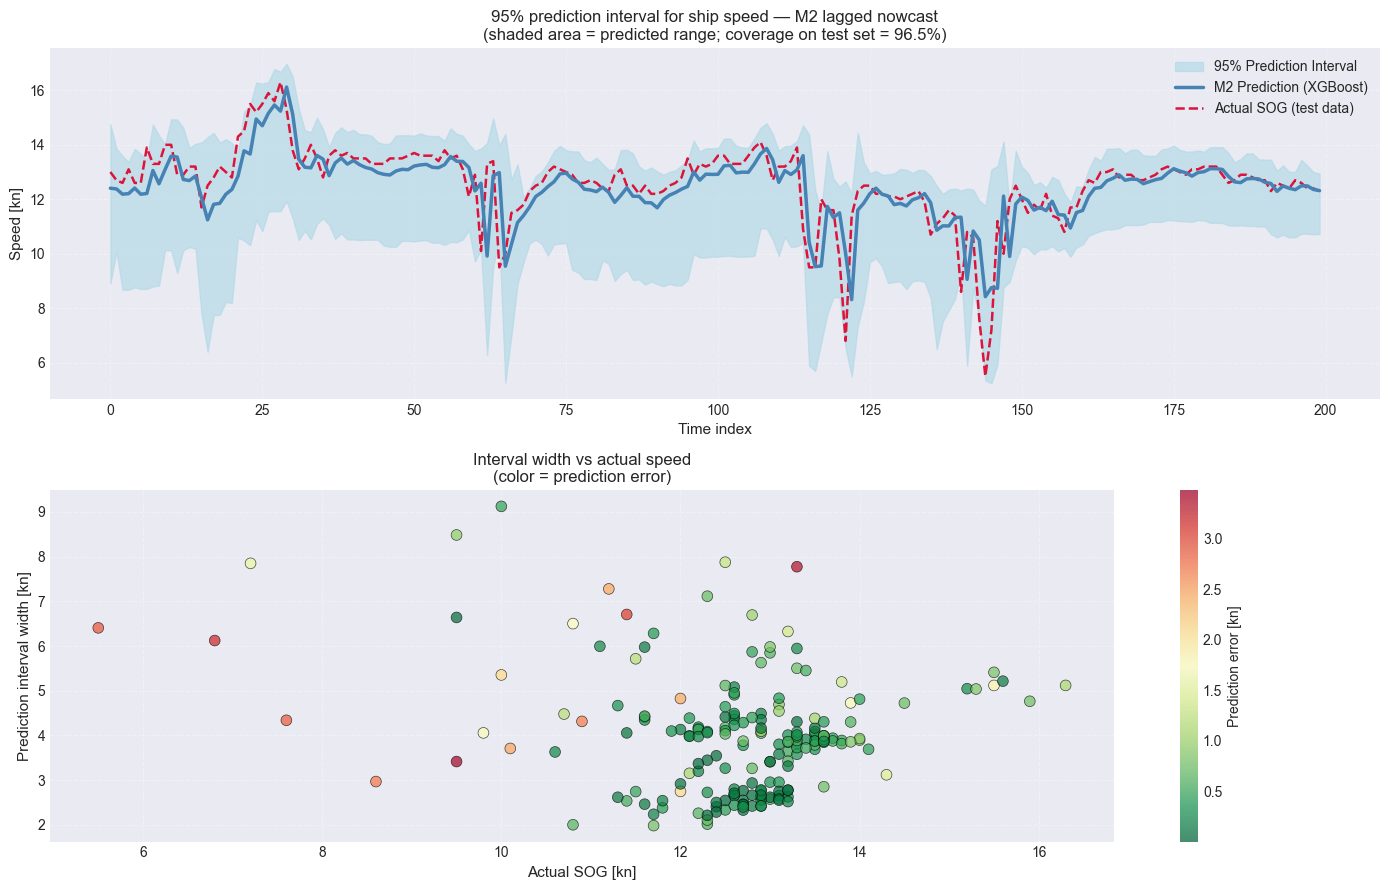

In [20]:
n_demo = min(200, len(y_test)) #  first 200 test points for demonstration

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# plot 1: view with shaded interval
ax = axes[0]

# shaded area is 95% prediction interval
ax.fill_between(
    range(n_demo),
    y_pred_lower[:n_demo],
    y_pred_upper[:n_demo],
    color='lightblue',
    alpha=0.6,
    label='95% Prediction Interval'
)

# central line = mean prediction (XGBoost M2)
ax.plot(
    range(n_demo),
    y_pred_xgb[:n_demo],
    color='steelblue',
    linewidth=2.5,
    label='M2 Prediction (XGBoost)',
    zorder=3
)

# actual speeds 
ax.plot(
    range(n_demo),
    y_test[:n_demo],
    color='crimson',
    linestyle='--',
    linewidth=1.8,
    label='Actual SOG (test data)',
    zorder=2
)

ax.set_xlabel("Time index", fontsize=11)
ax.set_ylabel("Speed [kn]", fontsize=11)
ax.set_title(
    "95% prediction interval for ship speed — M2 lagged nowcast\n"
    f"(shaded area = predicted range; coverage on test set = {coverage:.1f}%)",
    fontsize=12
)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

# plot 2 - interval width vs actual speed
ax = axes[1]

scatter = ax.scatter(
    y_test[:n_demo],
    interval_width[:n_demo],
    c=np.abs(y_test[:n_demo] - y_pred_xgb[:n_demo]),
    cmap='RdYlGn_r',
    s=60,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

ax.set_xlabel("Actual SOG [kn]", fontsize=11)
ax.set_ylabel("Prediction interval width [kn]", fontsize=11)
ax.set_title("Interval width vs actual speed\n(color = prediction error)", fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Prediction error [kn]', fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'prediction_intervals_95percent.png', dpi=150, bbox_inches='tight')
plt.show()
